This method gives a pretty descent result with default values of the algorithms.

With a test set using 20% of the full data set, we have an ROC AUC of 0.92

As the data set is unbalanced, we use an oversampling method (SMOTE) to obtain a balanced set. After that, we train a Random Forest classifier

In [1]:
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

### Build the data set from file

In [2]:
credit_cards=pd.read_csv('../input/creditcard.csv')

columns=credit_cards.columns
# The labels are in the last column ('Class'). Simply remove it to obtain features columns
features_columns=columns.delete(len(columns)-1)

features=credit_cards[features_columns]
labels=credit_cards['Class']

### Build train and test sets (20% of data reserved to test set)

In [3]:
features_train, features_test, labels_train, labels_test = train_test_split(features, 
                                                                            labels, 
                                                                            test_size=0.2, 
                                                                            random_state=0)

### Create from train set a new data set to obtain a balanced data set using SMOTE

In [4]:
oversampler=SMOTE(random_state=0)
os_features,os_labels=oversampler.fit_sample(features_train,labels_train)

In [5]:
# verify new data set is balanced
len(os_labels[os_labels==1])

227454

### Perform training of the random forest using the (over sampled) train set

In [6]:
clf=RandomForestClassifier(random_state=0)
clf.fit(os_features,os_labels)

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='gini',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_split=1e-07, min_samples_leaf=1,
            min_samples_split=2, min_weight_fraction_leaf=0.0,
            n_estimators=10, n_jobs=1, oob_score=False, random_state=0,
            verbose=0, warm_start=False)

In [7]:
# perform predictions on test set
actual=labels_test
predictions=clf.predict(features_test)

### confusion matrix on test set gives an encouraging result

In [8]:
confusion_matrix(actual,predictions)

array([[56846,    15],
       [   17,    84]])

### Let's go further and use the roc_auc indicator 

#### see https://datamize.wordpress.com/2015/01/24/how-to-plot-a-roc-curve-in-scikit-learn for a quick introduction

In [9]:
from sklearn.metrics import roc_curve, auc

false_positive_rate, true_positive_rate, thresholds = roc_curve(actual, predictions)
roc_auc = auc(false_positive_rate, true_positive_rate)
print (roc_auc)

0.915709683559


### According to the previous article, this result can be considered as very good as it is between 0.9 and 1

### Let's plot a shiny curve for the final result

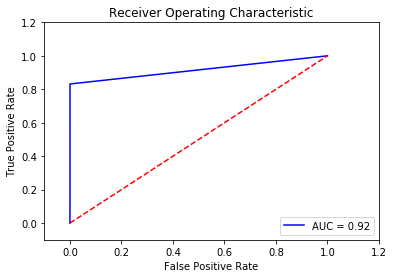

In [10]:
import matplotlib.pyplot as plt
plt.title('Receiver Operating Characteristic')
plt.plot(false_positive_rate, true_positive_rate, 'b', label='AUC = %0.2f'% roc_auc)
plt.legend(loc='lower right')
plt.plot([0,1],[0,1],'r--')
plt.xlim([-0.1,1.2])
plt.ylim([-0.1,1.2])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')

## Acknoledgments

Many thank's to [AtherRizvi][1] and it's [notebook][2] for the informations about ROC and AUC


  [1]: https://www.kaggle.com/ather123
  [2]: https://www.kaggle.com/ather123/d/dalpozz/creditcardfraud/randomforestclassifier-solution/notebook/ "notebook"